# Forward OT Solutions for Bilinear Logo Costs

This notebook generates the forward-solution figure for the inverse optimal
transport section. The same OT4ML point clouds used for the earlier logo
construction are matched with the bilinear cost
$$
    c_A(x,y)=\langle Ax,y\rangle.
$$
For equal weights, the optimal couplings form a face of the scaled Birkhoff
polytope. The first two panels display rank-one bilinear costs with a tiny
transverse perturbation: if $e=(1,1)^\top$ and $\delta=10^{-3}$, then
$$
    A_h=-e_1e^\top+\delta e_2e^\top,\qquad
    A_v=\delta e_1e^\top-e_2e^\top.
$$
The $\delta$ terms break the large ties created by the pure horizontal and
vertical scores while preserving rank one. The last two panels use $-I$ (the
quadratic $W_2$ assignment, up to marginal-only terms) and $+I$ (anti-$W_2$).


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment

from figure_style import BLUE, RED, figure_dir, save_pdf, setup_matplotlib

setup_matplotlib()

FIGURE_NAME = "inverse-ot-bilinear-logo-map"
OUTPUT_DIR = figure_dir(FIGURE_NAME)
THUMB_DIR = FIGROOT / "thumbnails"
THUMB_DIR.mkdir(parents=True, exist_ok=True)


## OT4ML point clouds

The letter strokes are encoded as six-row spans. Each span contributes one red source atom near its left end and one blue target atom near its right end. This is the point-cloud construction from the earlier logo experiments, embedded directly in the figure notebook so the `logo/` workspace can stay empty.


In [2]:
SPAN_GLYPHS = {
    "O": [
        [(1.72, 3.08)],
        [(0.52, 4.28)],
        [(0.0, 5.0)],
        [(0.0, 5.0)],
        [(0.52, 4.28)],
        [(1.72, 3.08)],
    ],
    "T": [
        [(0.0, 5.0)],
        [(0.0, 5.0)],
        [(2.0, 3.0)],
        [(2.0, 3.0)],
        [(2.0, 3.0)],
        [(2.0, 3.0)],
    ],
    "4": [
        [(0.0, 1.0), (4.0, 5.0)],
        [(0.0, 1.0), (4.0, 5.0)],
        [(0.0, 5.0)],
        [(0.0, 5.0)],
        [(4.0, 5.0)],
        [(4.0, 5.0)],
    ],
    "M": [
        [(0.0, 1.0), (4.0, 5.0)],
        [(0.0, 2.0), (3.0, 5.0)],
        [(0.0, 1.0), (2.0, 3.0), (4.0, 5.0)],
        [(0.0, 1.0), (2.0, 3.0), (4.0, 5.0)],
        [(0.0, 1.0), (4.0, 5.0)],
        [(0.0, 1.0), (4.0, 5.0)],
    ],
    "L": [
        [(0.0, 1.0)],
        [(0.0, 1.0)],
        [(0.0, 1.0)],
        [(0.0, 1.0)],
        [(0.0, 5.0)],
        [(0.0, 5.0)],
    ],
}


def ot4ml_points(
    word="OT4ML",
    cell=1.0,
    row_step=1.25,
    gap=1.05,
    cap_inset=0.08,
    jitter=0.015,
    seed=4,
):
    rng = np.random.default_rng(seed)
    sources = []
    targets = []

    x0 = 0.0
    for char in word:
        glyph = SPAN_GLYPHS[char]
        height = len(glyph)
        width = 5
        for row, spans in enumerate(glyph):
            y = (height - 1 - row) * row_step
            for left, right in spans:
                source = np.array([x0 + (left + cap_inset) * cell, y + 0.5 * cell])
                target = np.array([x0 + (right - cap_inset) * cell, y + 0.5 * cell])
                sources.append(tuple(source + rng.normal(scale=jitter, size=2)))
                targets.append(tuple(target + rng.normal(scale=jitter, size=2)))
        x0 += width * cell + gap

    source = np.array(sources, dtype=float)
    target = np.array(targets, dtype=float)
    midpoint = np.vstack([source, target]).mean(axis=0)
    return source - midpoint, target - midpoint


source, target = ot4ml_points()
all_points = np.vstack([source, target])
pad_x = 0.03 * (all_points[:, 0].max() - all_points[:, 0].min())
pad_y = 0.16 * (all_points[:, 1].max() - all_points[:, 1].min())
XLIM = (all_points[:, 0].min() - pad_x, all_points[:, 0].max() + pad_x)
YLIM = (all_points[:, 1].min() - pad_y, all_points[:, 1].max() + pad_y)


## Forward solutions for four matrices

For a matrix $A$, the equal-weight discrete OT solution set is
$$
    \mathcal P_A = \arg\min_{P\in\mathbf U(a,b)} \langle C(A),P\rangle,
    \qquad C(A)_{i,j}=\langle Ax_i,y_j\rangle.
$$
Rank-deficient choices of $A$ can create large optimal faces. The displayed
horizontal and vertical examples therefore use a tiny explicit perturbation in
the transverse direction, rather than relying only on numerical tie-breaking.
The cost matrix depends linearly on $A$, while the solution correspondence is
polyhedral; a tie-broken selection is constant on normal-cone cells.


In [3]:
DELTA = 1e-3
E = np.ones(2)
E1 = np.array([1.0, 0.0])
E2 = np.array([0.0, 1.0])

A_HORIZONTAL = np.outer(-E1 + DELTA * E2, E)
A_VERTICAL = np.outer(DELTA * E1 - E2, E)

MATRIX_SPECS = [
    (
        "horizontal",
        r"horizontal, $A_h=(-e_1+\delta e_2)e^\top$",
        A_HORIZONTAL,
    ),
    (
        "vertical",
        r"vertical, $A_v=(\delta e_1-e_2)e^\top$",
        A_VERTICAL,
    ),
    (
        "w2",
        r"quadratic $W_2$, $A=-I$",
        -np.eye(2),
    ),
    (
        "anti",
        r"anti-$W_2$, $A=+I$",
        np.eye(2),
    ),
]


def cost_matrix(source, target, A):
    return source @ A.T @ target.T


def assignment_for_matrix(A):
    cost = cost_matrix(source, target, A)
    # The displayed rank-one costs include a tiny analytic delta perturbation.
    # This final index term is only a deterministic fallback for exact numerical ties.
    index_tie = np.abs(np.arange(cost.shape[0])[:, None] - np.arange(cost.shape[1])[None, :])
    rows, cols = linear_sum_assignment(cost + 1e-9 * index_tie)
    assignment = np.empty(source.shape[0], dtype=int)
    assignment[rows] = cols
    return assignment


def draw_map(ax, assignment, *, title=None, title_size=9.0):
    for i, j in enumerate(assignment):
        ax.plot(
            [source[i, 0], target[j, 0]],
            [source[i, 1], target[j, 1]],
            color="#222222",
            alpha=0.40,
            lw=0.78,
            solid_capstyle="round",
            zorder=1,
        )
    ax.scatter(source[:, 0], source[:, 1], s=18, c=RED, edgecolors="white", linewidths=0.25, zorder=3)
    ax.scatter(target[:, 0], target[:, 1], s=18, c=BLUE, edgecolors="white", linewidths=0.25, zorder=4)
    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=title_size, pad=3.0)

assignments = {key: assignment_for_matrix(A) for key, _, A in MATRIX_SPECS}


## Render figure

The individual PDFs are used by the LaTeX figure. The summary PNG is used by the notebook gallery and by the MyST web book.


In [4]:
import contextlib
import io

with contextlib.redirect_stderr(io.StringIO()):
    for key, _, _ in MATRIX_SPECS:
        fig, ax = plt.subplots(figsize=(5.15, 1.58))
        draw_map(ax, assignments[key])
        save_pdf(fig, OUTPUT_DIR / f"{key}.pdf", pad_inches=0.018)
        plt.close(fig)

    fig, axes = plt.subplots(2, 2, figsize=(10.2, 4.0))
    for ax, (key, title, _) in zip(axes.ravel(), MATRIX_SPECS):
        draw_map(ax, assignments[key], title=title, title_size=8.8)
    fig.subplots_adjust(left=0.01, right=0.99, bottom=0.02, top=0.92, wspace=0.04, hspace=0.32)
    save_pdf(fig, OUTPUT_DIR / "summary.pdf", pad_inches=0.025)
    thumb_path = THUMB_DIR / f"{FIGURE_NAME}.png"
    fig.savefig(thumb_path, dpi=190, bbox_inches="tight", pad_inches=0.025, facecolor="white")
    plt.close(fig)

print(f"Wrote {thumb_path}")


Wrote /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/inverse-ot-bilinear-logo-map.png


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


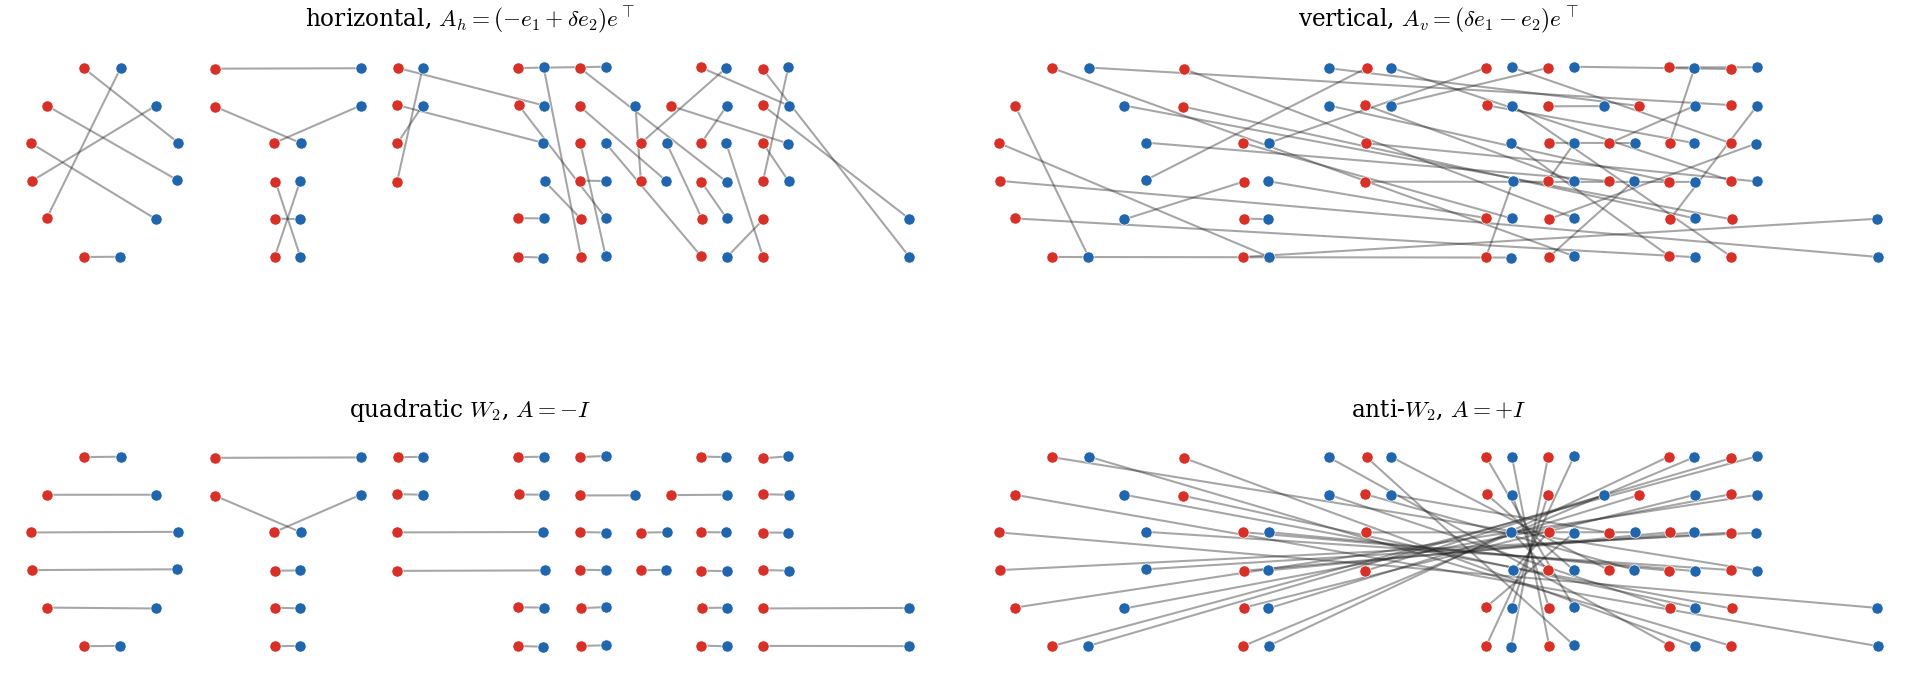

In [5]:
from IPython.display import Image, display

display(Image(filename=str(thumb_path)))
